In [1]:
import geopandas as gpd
import pandas as pd

import mapillary as mly

import glob

from datetime import datetime



### osm-netzwerk einlesen

In [2]:
#set_date = "251010"
#set_date = "251022"
#set_date = "251115"
#set_date = "251215"
#set_date = "260129"
set_date = "260410"

access_network = gpd.read_parquet(
    f"processed_osm_files/processed_access_restrictions_network_germany_{set_date}.parquet"
)


print("number of access-network segments:", len(access_network))
#print("number of motorways:", len(motorways))


number of access-network segments: 16287670


In [3]:
access_network.head()


,osm_id,highway,access,vehicle,motor_vehicle,motorcar,hgv,bicycle,motorcycle,foot,...,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name,ref,surface,width,geometry
0,92,residential,None,None,None,None,None,None,None,None,...,30,None,None,None,None,Eigenheimstraße,None,asphalt,None,"LINESTRING (13.73698 51.01663, 13.73716 51.016..."
1,93,residential,None,None,None,None,None,None,None,None,...,30,None,None,None,None,Eigenheimberg,None,asphalt,None,"LINESTRING (13.73939 51.01669, 13.73967 51.016..."
2,99,tertiary,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,asphalt,None,"LINESTRING (11.36639 48.17411, 11.36643 48.174..."
3,100,secondary,None,None,None,None,None,use_sidepath,None,use_sidepath,...,100,None,None,None,None,None,None,asphalt,None,"LINESTRING (11.33038 48.18011, 11.33033 48.180..."
4,103,residential,None,None,None,None,None,None,None,None,...,5,None,None,None,None,Altmockritz,None,None,None,"LINESTRING (13.74127 51.01615, 13.74149 51.016..."


In [4]:
access_network.columns


Index(['osm_id', 'highway', 'access', 'vehicle', 'motor_vehicle', 'motorcar',
       'hgv', 'bicycle', 'motorcycle', 'foot', 'maxweight', 'maxaxleload',
       'maxwidth', 'maxheight', 'maxlength', 'maxspeed',
       'maxspeed_conditional', 'maxspeed_backward', 'maxspeed_forward',
       'maxspeed_type', 'name', 'ref', 'surface', 'width', 'geometry'],
      dtype='object')

In [5]:
ACCESS_MATCH_COLUMNS = [
    "access",
    "vehicle",
    "motor_vehicle",
    "motorcar",
    "hgv",
    "bicycle",
    "motorcycle",
    "foot",
]

filtered_access_segments = access_network[
    access_network[ACCESS_MATCH_COLUMNS].notna().any(axis=1)
].copy()

# Compatibility aliases for cells still following the cycleway template structure.
#cycleways = access_network
#filtered_cycleways = filtered_access_segments

len(filtered_access_segments)


4279710

In [6]:
filtered_access_segments.to_parquet(
    f"processed_osm_files/filtered_access_restrictions_segments_germany_{set_date}.parquet"
)

### mapillary traffic signs einlesen

In [7]:
## TRAFFIC SIGNS
# https://www.mapillary.com/developer/api-documentation/traffic-signs?locale=

parquet_files = glob.glob("../../output/mapillary_traffic-signs_*.parquet")
dates = sorted({f.split("_")[-1].replace(".parquet", "") for f in parquet_files})
print("Dates found in filenames:", dates)

mapillary_trafficsigns = gpd.GeoDataFrame(
    pd.concat([gpd.read_parquet(file_path) for file_path in parquet_files], ignore_index=True),
    crs=gpd.read_parquet(parquet_files[0]).crs,
)

ACCESS_SIGN_TO_VZ = {
    "regulatory--road-closed-to-vehicles--g3": 250,
    "regulatory--no-motor-vehicles-except-motorcycles--g1": 251,
    "regulatory--no-heavy-goods-vehicles--g1": 253,
    "regulatory--no-bicycles--g1": 254,
    "regulatory--no-motorcycles--g1": 255,
    "regulatory--no-pedestrians--g1": 259,
    "regulatory--no-motor-vehicles--g1": 260,
}

ACCESS_SIGN_TO_GROUP = {
    "regulatory--road-closed-to-vehicles--g3": "general",
    "regulatory--no-motor-vehicles-except-motorcycles--g1": "motor_vehicle",
    "regulatory--no-heavy-goods-vehicles--g1": "hgv",
    "regulatory--no-bicycles--g1": "bicycle",
    "regulatory--no-motorcycles--g1": "motorcycle",
    "regulatory--no-pedestrians--g1": "foot",
    "regulatory--no-motor-vehicles--g1": "motor_vehicle",
}

mapillary_access_signs = mapillary_trafficsigns[
    mapillary_trafficsigns.value.isin(ACCESS_SIGN_TO_VZ.keys())
].copy()
mapillary_access_signs = mapillary_access_signs.drop_duplicates(subset=["id"])
mapillary_access_signs["VZ"] = mapillary_access_signs["value"].map(ACCESS_SIGN_TO_VZ)
mapillary_access_signs["expected_access_group"] = mapillary_access_signs["value"].map(ACCESS_SIGN_TO_GROUP)
mapillary_access_signs["expected_osm_tags"] = mapillary_access_signs["expected_access_group"].map({
    "general": "access=* or vehicle=*",
    "motor_vehicle": "motor_vehicle=*, motorcar=* or vehicle=*",
    "hgv": "hgv=* or motor_vehicle=*",
    "bicycle": "bicycle=* or access=*",
    "motorcycle": "motorcycle=* or motor_vehicle=*",
    "foot": "foot=* or access=*",
})

# Compatibility aliases for downstream cells copied from the cycleway notebook.
mapillary_trafficsigns_cw = mapillary_access_signs
mapillary_trafficsigns_access = mapillary_access_signs.copy()

mapillary_access_signs


Dates found in filenames: ['latest']


,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y,VZ,expected_access_group,expected_osm_tags
56,POINT (8.45676 49.59988),2018-08-23,255593302978489,2018-08-23,regulatory--road-closed-to-vehicles--g3,8576,5584,250,general,access=* or vehicle=*
90,POINT (8.45689 49.60453),2018-08-23,897590367749630,2018-08-23,regulatory--no-heavy-goods-vehicles--g1,8576,5584,253,hgv,hgv=* or motor_vehicle=*
148,POINT (8.45707 49.60456),2017-01-07,270782684746480,2017-01-07,regulatory--no-heavy-goods-vehicles--g1,8576,5584,253,hgv,hgv=* or motor_vehicle=*
179,POINT (8.45933 49.59161),2022-12-14,879944383010190,2026-02-13,regulatory--no-bicycles--g1,8576,5585,254,bicycle,bicycle=* or access=*
182,POINT (8.45712 49.58994),2017-01-22,978633062880219,2025-08-29,regulatory--no-heavy-goods-vehicles--g1,8576,5585,253,hgv,hgv=* or motor_vehicle=*
...,...,...,...,...,...,...,...,...,...,...
6668791,POINT (10.30965 53.43603),2018-10-28,161374219179194,2018-10-28,regulatory--road-closed-to-vehicles--g3,8661,5303,250,general,access=* or vehicle=*
6668798,POINT (10.30989 53.43607),2018-02-28,1134219600386066,2018-02-28,regulatory--road-closed-to-vehicles--g3,8661,5303,250,general,access=* or vehicle=*
6668801,POINT (10.32001 53.43621),2018-02-28,1625810840937876,2018-02-28,regulatory--road-closed-to-vehicles--g3,8661,5303,250,general,access=* or vehicle=*
6668814,POINT (10.31983 53.43617),2016-11-02,521878588981216,2016-11-02,regulatory--road-closed-to-vehicles--g3,8661,5303,250,general,access=* or vehicle=*


In [8]:
mapillary_access_signs.to_parquet(
    f"processed_mapillary_files/mapillary_access_signs_germany_{set_date}.parquet"
)

In [9]:
### cehck if really inside germany
import gzip
import json

gz_path = "../utils/OSMB-germany.geojson.gz"

# Try GDAL's virtual filesystem (/vsigzip) via pyogrio engine first
try:
    germany_boundary = gpd.read_file(f"/vsigzip/{gz_path}", engine="pyogrio")
except Exception:
    # Fallback: manual gzip decompress + GeoJSON parse
    with gzip.open(gz_path, "rt", encoding="utf-8") as f:
        geojson_obj = json.load(f)
    germany_boundary = gpd.GeoDataFrame.from_features(geojson_obj, crs="EPSG:4326")

# mapillary_trafficsigns_cw = gpd.sjoin(mapillary_trafficsigns_cw, germany_boundary[['geometry']], predicate='within', how='inner')
# mapillary_trafficsigns_cw = mapillary_trafficsigns_cw.drop(columns=['index_right'])

In [10]:
# Clip traffic signs to Germany boundary

mapillary_access_signs = gpd.sjoin(
    mapillary_access_signs,
    germany_boundary[["geometry"]],
    predicate="within",
    how="inner",
)
mapillary_access_signs = mapillary_access_signs.drop(columns=["index_right"])


print(f"Traffic signs after clipping to Germany: {len(mapillary_access_signs)}")

Traffic signs after clipping to Germany: 180280


<Axes: xlabel='last_seen_at'>

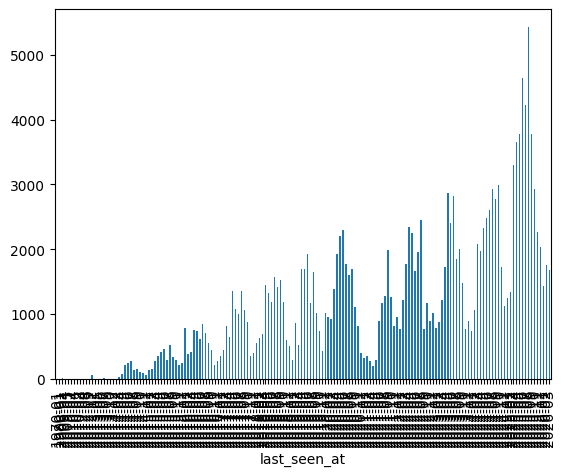

In [11]:
mapillary_access_signs.last_seen_at.str[:-3].value_counts().sort_index().plot(kind="bar")


#### Zeitfilter 

In [12]:
## is newer than 2025-01-01


mapillary_access_signs = mapillary_access_signs[
    mapillary_access_signs["last_seen_at"] > "2025-07-01"
].copy()

# Compatibility alias
mapillary_trafficsigns_cw = mapillary_access_signs

len(mapillary_access_signs)

25433

In [13]:
mapillary_access_signs

,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y,VZ,expected_access_group,expected_osm_tags
179,POINT (8.45933 49.59161),2022-12-14,879944383010190,2026-02-13,regulatory--no-bicycles--g1,8576,5585,254,bicycle,bicycle=* or access=*
182,POINT (8.45712 49.58994),2017-01-22,978633062880219,2025-08-29,regulatory--no-heavy-goods-vehicles--g1,8576,5585,253,hgv,hgv=* or motor_vehicle=*
260,POINT (8.46312 49.59679),2019-03-31,1002303453851763,2026-02-13,regulatory--no-heavy-goods-vehicles--g1,8577,5584,253,hgv,hgv=* or motor_vehicle=*
283,POINT (8.46146 49.60311),2015-08-02,812611382967209,2026-02-13,regulatory--no-heavy-goods-vehicles--g1,8577,5584,253,hgv,hgv=* or motor_vehicle=*
286,POINT (8.46186 49.60515),2026-02-13,2416628158788162,2026-02-13,regulatory--no-heavy-goods-vehicles--g1,8577,5584,253,hgv,hgv=* or motor_vehicle=*
...,...,...,...,...,...,...,...,...,...,...
6667548,POINT (10.23322 53.44819),2025-10-19,1333527318372432,2025-10-19,regulatory--road-closed-to-vehicles--g3,8657,5303,250,general,access=* or vehicle=*
6668211,POINT (10.26201 53.47198),2025-12-05,847303957666794,2025-12-05,regulatory--road-closed-to-vehicles--g3,8659,5301,250,general,access=* or vehicle=*
6668510,POINT (10.30394 53.44081),2018-02-28,473625707048571,2025-10-19,regulatory--road-closed-to-vehicles--g3,8660,5303,250,general,access=* or vehicle=*
6668743,POINT (10.31009 53.43606),2019-06-28,3098049587134678,2025-12-05,regulatory--road-closed-to-vehicles--g3,8661,5303,250,general,access=* or vehicle=*


<Axes: xlabel='last_seen_at'>

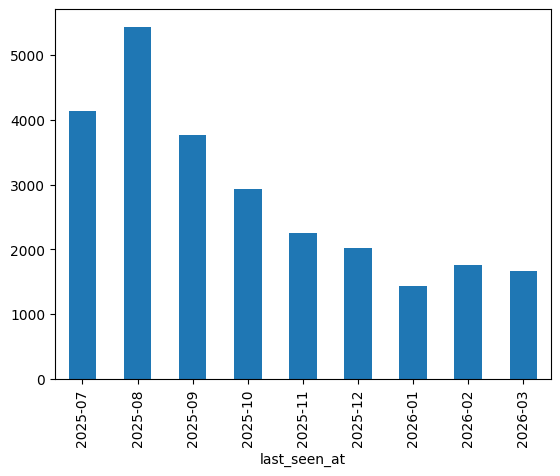

In [14]:
mapillary_access_signs.last_seen_at.str[:-3].value_counts().sort_index().plot(kind="bar")

In [15]:
## at least 12 months between first and last seen (to avoid temporary signs)
## might need to adjust this

zeitspanne = 9


def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)


mapillary_access_signs_temp = mapillary_access_signs[
    mapillary_access_signs.apply(
        lambda row: months_between(row["first_seen_at"], row["last_seen_at"]) >= zeitspanne,
        axis=1,
    )
].copy()

# Compatibility alias
mapillary_trafficsigns_cw_temp = mapillary_access_signs_temp

len(mapillary_access_signs_temp)

6862

<Axes: xlabel='last_seen_at'>

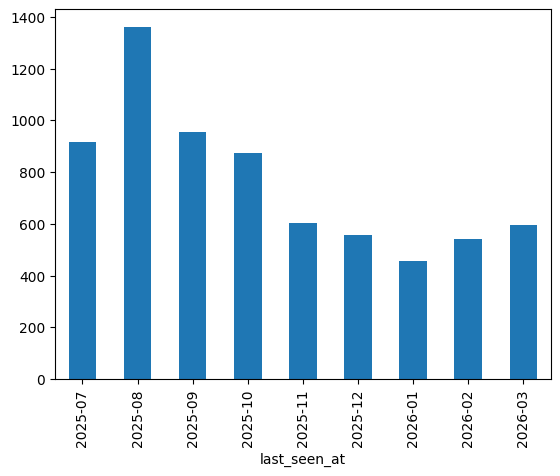

In [16]:
mapillary_access_signs_temp.last_seen_at.str[:-3].value_counts().sort_index().plot(kind="bar")

<Axes: >

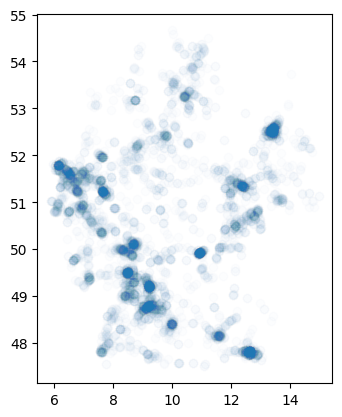

In [17]:
mapillary_access_signs_temp.plot(alpha=0.01)

#### Räumliche Prüfung 

In [18]:
## now create a buffer around the traffic signs to check if there is a matching access restriction nearby
buffered_access_30 = mapillary_access_signs_temp.to_crs(25833).copy()
buffered_access_25 = mapillary_access_signs_temp.to_crs(25833).copy()

buffered_access_30["geometry"] = buffered_access_30.geometry.buffer(30)
buffered_access_25["geometry"] = buffered_access_25.geometry.buffer(25)

buffered_access_30 = buffered_access_30.to_crs(mapillary_access_signs_temp.crs)
buffered_access_25 = buffered_access_25.to_crs(mapillary_access_signs_temp.crs)

# Compatibility aliases
df_buffered_30 = buffered_access_30
df_buffered_25 = buffered_access_25


In [19]:
# helper 
def mark_intersections(buffered_df, target_layer, column_name="has_intersection"):
    """
    Marks which geometries in `buffered_df` intersect with `target_layer`.

    Parameters:
    - buffered_df (GeoDataFrame): The GeoDataFrame containing buffered geometries.
    - target_layer (GeoDataFrame): The GeoDataFrame to check for intersections (e.g., cycleways, motorways).
    - column_name (str): Name of the column to add/overwrite in `buffered_df` indicating intersection (bool).

    Returns:
    - GeoDataFrame: `buffered_df` with a new boolean column `column_name`.
    """
    # Ensure CRS matches
    buffered_df = buffered_df.to_crs(target_layer.crs)

    # Perform spatial join to find intersecting geometries
    joined = gpd.sjoin(buffered_df, target_layer, how="inner", predicate="intersects")

    # Initialize the new column to False
    buffered_df[column_name] = False

    # Set True for geometries that intersect
    matches = joined.index.unique()
    buffered_df.loc[matches, column_name] = True

    return buffered_df


In [20]:
ACCESS_LAYER_COLUMNS = {
    "general": ["access", "vehicle"],
    "motor_vehicle": ["motor_vehicle", "motorcar", "vehicle", "access"],
    "hgv": ["hgv", "motor_vehicle", "vehicle", "access"],
    "bicycle": ["bicycle", "vehicle", "access"],
    "motorcycle": ["motorcycle", "motor_vehicle", "vehicle", "access"],
    "foot": ["foot", "access"],
}


def build_access_layers(gdf):
    layers = {}
    for group, columns in ACCESS_LAYER_COLUMNS.items():
        available = [column for column in columns if column in gdf.columns]
        layers[group] = gdf[gdf[available].notna().any(axis=1)].copy() if available else gdf.iloc[0:0].copy()
    return layers


def mark_access_matches(buffered_df, layers, column_name="has_access_match"):
    buffered_df = buffered_df.copy()
    buffered_df[column_name] = False

    for group, layer in layers.items():
        if layer.empty:
            continue

        mask = buffered_df["expected_access_group"] == group
        if not mask.any():
            continue

        matched = mark_intersections(
            buffered_df.loc[mask].copy(),
            layer,
            column_name=column_name,
        )
        buffered_df.loc[matched.index, column_name] = matched[column_name]

    return buffered_df


access_layers = build_access_layers(filtered_access_segments)

buffered_access_30 = mark_access_matches(buffered_access_30, access_layers, column_name="has_access_match")
buffered_access_25 = mark_access_matches(buffered_access_25, access_layers, column_name="has_access_match")


# Compatibility aliases
buffered_access_30["has_cw_intersection"] = buffered_access_30["has_access_match"]
buffered_access_25["has_cw_intersection"] = buffered_access_25["has_access_match"]


df_buffered_30 = buffered_access_30
df_buffered_25 = buffered_access_25


In [21]:
df_buffered_30["buffer_size"] = 30
df_buffered_25["buffer_size"] = 25

In [22]:
#df_buffered.id.unique()

In [23]:
# An wie vielen Schildern gibt es bereits ein passendes Access-Tag in der Naehe?
buffered_access_30.has_access_match.value_counts()

has_access_match
True     4872
False    1990
Name: count, dtype: int64

In [24]:
buffered_access_25.has_access_match.value_counts()

has_access_match
True     4685
False    2177
Name: count, dtype: int64

In [25]:
buffered_access_25_false = buffered_access_25[
    (buffered_access_25.has_access_match == False)
].copy()
len(buffered_access_25_false)

2177

In [26]:
buffered_access_30_false = buffered_access_30[
    (buffered_access_30.has_access_match == False)
].copy()
len(buffered_access_30_false)

1990

In [27]:
### just use 30m for now

In [ ]:
# Prioritaet wird direkt nach der Auswahl der finalen Kandidaten gesetzt.

In [ ]:
df_buffered_both_false = buffered_access_30_false.copy()
df_buffered_both_false["prio"] = df_buffered_both_false["buffer_size"].map({25: 1, 30: 0}).astype("Int64")
df_buffered_both_false

In [30]:
# interactive map
# df_buffered_false.explore(
#     color="red",
#     tiles="CartoDB positron",
#     popup=True,
#     tooltip=["value", "first_seen_at", "last_seen_at"]
# )

In [31]:
import json
import requests

#### clean up from existing maproulette challenge

In [32]:
### import the the flagged (not created, fixed) tasks from the challenge. 

# challenge_gdf = gpd.read_file("challenge_52916_data_f_mr.geojson")
#challenge_gdf.head()

with open("../utils/config_mapillary_privat.json", "r") as f:
    config = json.load(f)
API_KEY = config["API_KEY_MAPROULETTE"]

CHALLENGE_ID = 52916
BASE_URL = "https://maproulette.org/api/v2"

headers = {"apiKey": API_KEY}

# Single request to get all tasks as GeoJSON
r = requests.get(
    f"{BASE_URL}/challenge/view/{CHALLENGE_ID}",
    headers=headers
)
r.raise_for_status()
geojson_data = r.json()

# Convert directly to GeoDataFrame
challenge_gdf = gpd.GeoDataFrame.from_features(geojson_data, crs='EPSG:4326')

challenge_gdf=challenge_gdf[~challenge_gdf.mr_taskStatus.isin(["Fixed", "Created", "Skipped"])]

df_buffered_both_false = df_buffered_both_false.to_crs(4326)

# Find intersections
intersections = gpd.sjoin(df_buffered_both_false, challenge_gdf, how="left", predicate="intersects")

# Keep only rows that do NOT intersect (i.e., no match in challenge_gdf)
df_buffered_both_false_no_challenge = df_buffered_both_false.loc[intersections.index[intersections["index_right"].isna()]] 

len(df_buffered_both_false_no_challenge)


1989

### retrieve the image ID for the map features

In [33]:
#df_process_img= df_buffered_false.copy()
df_process_img= df_buffered_both_false_no_challenge[:100].copy()

In [34]:
import sys
import os
import json
import logging
from contextlib import contextmanager
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout


with open("../utils/config_mapillary_privat.json", "r") as f:
    config = json.load(f)

access_token = config["ACCESS_TOKEN"]
mly.interface.set_access_token(access_token)

for name in logging.root.manager.loggerDict:
    logging.getLogger(name).setLevel(logging.WARNING)
logging.basicConfig(level=logging.ERROR)


def get_image_id(map_feature_id):
    try:
        feature_str = mly.interface.feature_from_key(key=str(map_feature_id))
        feature = json.loads(feature_str)
        images = feature["features"]["properties"]["images"]["data"]
        return images[-1]["id"] if images else None
    except Exception:
        return None


def parallel_get_image_ids(ids, max_workers=8):
    results = [None] * len(ids)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(get_image_id, id_): idx for idx, id_ in enumerate(ids)}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Fetching image IDs"):
            idx = futures[future]
            try:
                results[idx] = future.result()
            except Exception:
                results[idx] = None
    return results


with suppress_stdout():
    df_process_img["image_id"] = parallel_get_image_ids(df_process_img["id"].tolist(), max_workers=5)


Fetching image IDs: 100%|██████████| 100/100 [00:11<00:00,  8.34it/s]


In [35]:
## https://www.mapillary.com/app/?pKey=1029316554880692

df_process_img.head()



,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y,VZ,expected_access_group,expected_osm_tags,has_access_match,has_cw_intersection,buffer_size,image_id
260,"POLYGON ((8.46353 49.59682, 8.46353 49.59679, ...",2019-03-31,1002303453851763,2026-02-13,regulatory--no-heavy-goods-vehicles--g1,8577,5584,253,hgv,hgv=* or motor_vehicle=*,False,False,30,890661763938945
283,"POLYGON ((8.46188 49.60313, 8.46188 49.60311, ...",2015-08-02,812611382967209,2026-02-13,regulatory--no-heavy-goods-vehicles--g1,8577,5584,253,hgv,hgv=* or motor_vehicle=*,False,False,30,798985344345167
12238,"POLYGON ((8.9058 49.43992, 8.9058 49.43989, 8....",2023-08-03,245754538282830,2025-12-12,regulatory--no-heavy-goods-vehicles--g1,8597,5595,253,hgv,hgv=* or motor_vehicle=*,False,False,30,829642193196273
12258,"POLYGON ((8.90157 49.44509, 8.90157 49.44507, ...",2023-09-24,616039663842594,2025-10-04,regulatory--road-closed-to-vehicles--g3,8597,5595,250,general,access=* or vehicle=*,False,False,30,1525677611909693
12324,"POLYGON ((8.90793 49.44688, 8.90793 49.44685, ...",2018-09-07,848186019101618,2025-09-10,regulatory--road-closed-to-vehicles--g3,8597,5595,250,general,access=* or vehicle=*,False,False,30,1141406090898664


In [36]:
# to points, to 4326

centroids = df_process_img.copy()
centroids=centroids.to_crs(25832)
centroids["geometry"] = centroids.geometry.centroid
centroids=centroids.to_crs(4326)

centroids.sort_values("last_seen_at")


,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y,VZ,expected_access_group,expected_osm_tags,has_access_match,has_cw_intersection,buffer_size,image_id
71359,POINT (8.3167 49.99457),2022-08-14,806986883647379,2025-07-05,regulatory--no-heavy-goods-vehicles--g1,8570,5556,253,hgv,hgv=* or motor_vehicle=*,False,False,30,725117936817524
80669,POINT (8.35844 49.8887),2020-03-29,876388593223758,2025-07-05,regulatory--no-motor-vehicles--g1,8572,5564,260,motor_vehicle,"motor_vehicle=*, motorcar=* or vehicle=*",False,False,30,779069832803395
71360,POINT (8.31669 49.99467),2022-08-14,806986876980713,2025-07-05,regulatory--no-heavy-goods-vehicles--g1,8570,5556,253,hgv,hgv=* or motor_vehicle=*,False,False,30,1230823551636616
36760,POINT (8.17324 50.02479),2022-08-15,395040119371349,2025-07-06,regulatory--no-heavy-goods-vehicles--g1,8563,5554,253,hgv,hgv=* or motor_vehicle=*,False,False,30,695508779973803
98512,POINT (8.4566 50.28052),2024-10-06,536489679001199,2025-07-09,regulatory--no-heavy-goods-vehicles--g1,8576,5536,253,hgv,hgv=* or motor_vehicle=*,False,False,30,1058470919603065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87866,POINT (8.40316 50.02629),2022-05-28,746983599655315,2026-03-05,regulatory--no-heavy-goods-vehicles--g1,8574,5554,253,hgv,hgv=* or motor_vehicle=*,False,False,30,891921642181887
87863,POINT (8.40366 50.02639),2020-05-22,1064482360745614,2026-03-05,regulatory--no-heavy-goods-vehicles--g1,8574,5554,253,hgv,hgv=* or motor_vehicle=*,False,False,30,1759003564499334
93147,POINT (8.43032 50.04241),2022-05-28,144861421453937,2026-03-06,regulatory--no-heavy-goods-vehicles--g1,8575,5553,253,hgv,hgv=* or motor_vehicle=*,False,False,30,4359647284352670
38290,POINT (8.1851 50.15602),2018-11-16,1158037577978440,2026-03-10,regulatory--no-heavy-goods-vehicles--g1,8564,5545,253,hgv,hgv=* or motor_vehicle=*,False,False,30,1208296144622983


In [37]:
value_to_vz = ACCESS_SIGN_TO_VZ
centroids["VZ"] = centroids["value"].map(value_to_vz)


In [ ]:
#centroids

In [38]:
centroids

,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y,VZ,expected_access_group,expected_osm_tags,has_access_match,has_cw_intersection,buffer_size,image_id
260,POINT (8.46312 49.59679),2019-03-31,1002303453851763,2026-02-13,regulatory--no-heavy-goods-vehicles--g1,8577,5584,253,hgv,hgv=* or motor_vehicle=*,False,False,30,890661763938945
283,POINT (8.46146 49.60311),2015-08-02,812611382967209,2026-02-13,regulatory--no-heavy-goods-vehicles--g1,8577,5584,253,hgv,hgv=* or motor_vehicle=*,False,False,30,798985344345167
12238,POINT (8.90538 49.4399),2023-08-03,245754538282830,2025-12-12,regulatory--no-heavy-goods-vehicles--g1,8597,5595,253,hgv,hgv=* or motor_vehicle=*,False,False,30,829642193196273
12258,POINT (8.90116 49.44507),2023-09-24,616039663842594,2025-10-04,regulatory--road-closed-to-vehicles--g3,8597,5595,250,general,access=* or vehicle=*,False,False,30,1525677611909693
12324,POINT (8.90751 49.44685),2018-09-07,848186019101618,2025-09-10,regulatory--road-closed-to-vehicles--g3,8597,5595,250,general,access=* or vehicle=*,False,False,30,1141406090898664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329964,POINT (8.68669 50.09818),2022-04-09,296864149192535,2025-08-17,regulatory--road-closed-to-vehicles--g3,8587,5549,250,general,access=* or vehicle=*,False,False,30,549868893121466
330033,POINT (8.69185 50.10411),2022-03-13,1304713773347086,2025-08-16,regulatory--road-closed-to-vehicles--g3,8587,5549,250,general,access=* or vehicle=*,False,False,30,939218158239191
330038,POINT (8.692 50.10427),2022-03-13,1304714000013730,2025-08-16,regulatory--road-closed-to-vehicles--g3,8587,5549,250,general,access=* or vehicle=*,False,False,30,1081859647422470
330081,POINT (8.69165 50.10293),2021-10-21,600713484293667,2025-08-02,regulatory--road-closed-to-vehicles--g3,8587,5549,250,general,access=* or vehicle=*,False,False,30,1091941776208462


In [ ]:
# centroids["prio_text"] = centroids["prio"].map({
#     0: "🟩 Task mit hoher Wahrscheinlichkeit valide",
#     1: "🟨 Task mit mittlerer Wahrscheinlichkeit valide",
#     2: "🟥 Task mit eher geringer Wahrscheinlichkeit valide"
# })

# centroids[["prio", "prio_text"]].head()

In [ ]:
#centroids.plot()

In [48]:
def to_maproulette_geojson_with_links(gdf, id_field="id", image_field="image_id"):
    features = []

    for _, row in gdf.iterrows():
        geom = row.geometry
        centroid = geom.centroid
        lat, lon = round(centroid.y, 6), round(centroid.x, 6)

        image_url = None
        image_id = None
        if pd.notna(row.get(image_field)):
            image_id = str(int(row[image_field]))
            image_url = (
                f"https://www.mapillary.com/app/?pKey={image_id}"
                "&focus=photo"
                "&trafficSign[]=regulatory--road-closed-to-vehicles--g3"
                "&trafficSign[]=regulatory--no-motor-vehicles-except-motorcycles--g1"
                "&trafficSign[]=regulatory--no-heavy-goods-vehicles--g1"
                "&trafficSign[]=regulatory--no-bicycles--g1"
                "&trafficSign[]=regulatory--no-motorcycles--g1"
                "&trafficSign[]=regulatory--no-pedestrians--g1"
                "&trafficSign[]=regulatory--no-motor-vehicles--g1"
            )


        instruction = f"""
### Aufgabe: Verkehrszeichen **DE:{row['VZ']}** pruefen und Access-Tag ergaenzen
Bitte schaue dir den Bereich rund um dieses erkannte Verkehrszeichen an. Vermutlich fehlt hier eine Zugangsbeschraenkung in OSM. Das naechste passende OSM-Segment ist mind. **{row['buffer_size']} Meter** entfernt.

---

### Bild und Karte

- [Mapillary-Bild anzeigen]({image_url})
(Hinweis: Die neueste Aufnahme hier ist von **{row['last_seen_at']}**)


---

### Nuetzliche Links

- [Traffic Sign Tool - DE:{row['VZ']}](https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:{row['VZ']})
- [OSM-Wiki: access](https://wiki.openstreetmap.org/wiki/Key:access)
- [OSM-Wiki: DE:access](https://wiki.openstreetmap.org/wiki/DE:Key:access)

---

Trage nur dann ein neues Tag ein, wenn die Beschraenkung vor Ort eindeutig erkennbar ist.
Achte auf Zusatzzeichen, Anlieger frei, zeitliche Einschraenkungen und Fahrtrichtung.
        """

        props = {
            "image_id": image_id,
            "Verkehrzeichen": str(row["VZ"]),
            "instruction": instruction,
            #"priority": row["prio"],
            #"name": row["prio_text"],
        }

        feature = {
            "type": "Feature",
            "geometry": row["geometry"].__geo_interface__,
            "properties": props,
            "id": str(row[id_field]),
        }

        features.append(feature)

    return {
        "type": "FeatureCollection",
        "features": features,
    }

In [49]:
maproulette_geojson = to_maproulette_geojson_with_links(centroids)

with open("maproulette_tasks_missing-access-restrictions.geojson", "w") as f:
    json.dump(maproulette_geojson, f)

In [ ]:
### Maproulette stuff....

## Add missing access restrictions based on Mapillary signs (Germany)

This campaign highlights regulatory prohibition signs from Mapillary that currently do not appear to have a nearby matching access-related tag in OSM.

Focus in V1 is on signs 250, 251, 253, 254, 255, 259 and 260.


1. Oeffne den Ort in **Mapillary**, in einer Kartenansicht und in deinem OSM-Editor.
2. Pruefe, ob das erkannte Verkehrszeichen tatsaechlich fuer den betroffenen Weg gilt.
3. Wenn in OSM noch kein passendes access-bezogenes Tag vorhanden ist, trage das fehlende Tag ein.
4. Achte auf Zusatzzeichen, Ausnahmen wie `Anlieger frei`, zeitliche Einschraenkungen und Fahrtrichtung.
5. Wenn die Situation unklar ist oder das Schild nicht eindeutig zum Weg gehoert, loese die Aufgabe nicht blind.


In [ ]:
'''
{{instruction}}
                                                                                             .
'''